# RA Task Analysis

## 1. Data cleaning

### 1.1 Data import

In [97]:
# import libraries
import os
from pathlib import Path

import pandas as pd

In [98]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ENV_PATH = PROJECT_ROOT / ".env"

try:
    from dotenv import load_dotenv

    load_dotenv(ENV_PATH)
except ImportError:
    if ENV_PATH.exists():
        for line in ENV_PATH.read_text().splitlines():
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, value = line.split("=", 1)
                os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

ads_path = DATA_DIR / "ra_task_ads.csv"
firms_path = DATA_DIR / "ra_task_firms.csv"

In [99]:
ads = pd.read_csv(ads_path)
firms = pd.read_csv(firms_path)

print(f"ads rows: {len(ads):,}; columns: {ads.shape[1]}")
print(f"firms rows: {len(firms):,}; columns: {firms.shape[1]}")

ads rows: 612; columns: 10
firms rows: 5,463; columns: 4


In [100]:
ads.head()

,id,公司名称,关联公司名称,岗位,岗位描述,岗位标签,待遇,学历,所在城市,发布时间
0,1,中国平安人寿保险股份有限公司广东分公司,中国平安人寿保险股份有限公司广东分公司,兴业银行渠道经理,<$&0006&$><$&0007&$> <$&0006&$><$&0007&$> ...,销售<$&0007&$>银行<$&0007&$>金融行业<$&0007&$>公关<$&000...,1-2万,本科,广州市,2023-10-30 00:00:00
1,2,上海璞泰来新能源科技股份有限公司,上海璞泰来新能源科技股份有限公司,研发工程师,<$&0006&$><$&0007&$><$&0005&$><$&0005&$><$&000...,NaN,NaN,本科,东莞市,2016-11-28 00:00:00
2,3,嘉亨家化股份有限公司,嘉亨家化股份有限公司,水电工程师,<$&0006&$><$&0007&$> <$&0006&$><$&0007&$> ...,电工证,4-6千/月,中技,泉州市,2020-06-23 00:00:00
3,4,中国平安人寿保险股份有限公司成都市金堂支公司淮口营销服务部,中国平安人寿保险股份有限公司成都市金堂支公司淮口营销服务部,金融销售培训讲师+周末双休,<$&0006&$><$&0007&$> <$&0006&$><$&0007&$> ...,产品培训<$&0007&$>入司培训<$&0007&$>课程安排<$&0007&$>销售<$...,10-15万/年,大专,成都市,2023-03-27 00:00:00
4,5,成都天箭科技股份有限公司,成都天箭科技股份有限公司,FPGA开发工程师,<$&0006&$><$&0007&$> <$&0006&$><$&0007&$> ...,芯片<$&0007&$>xilinx<$&0007&$>vhdl,4-7千,硕士,成都市,2022-07-10 00:00:00


In [101]:
firms.head()

,股票代码,证券简称,公司全称,证监会行业
0,000001.SZ,平安银行,平安银行股份有限公司,NaN
1,000002.SZ,万科A,万科企业股份有限公司,NaN
2,000004.SZ,国华退,深圳国华网安科技股份有限公司,NaN
3,000006.SZ,深振业A,深圳市振业(集团)股份有限公司,NaN
4,000007.SZ,全新好,深圳市全新好股份有限公司,NaN


### 1.2 Clean garbled text markers

Remove malformed markers like `<$&0006&$>` from text fields.

In [102]:
garbled_pattern = r"<\$&\d+&\$>"
garbled_counts = {}

for df_name, df in [("ads", ads), ("firms", firms)]:
    for col in df.select_dtypes(include="object").columns:
        text = df[col].astype("string")
        affected_rows = text.str.contains(garbled_pattern, regex=True, na=False).sum()

        if affected_rows:
            garbled_counts[f"{df_name}.{col}"] = int(affected_rows)
            df[col] = (
                text.str.replace(garbled_pattern, "", regex=True)
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            )

garbled_counts

{'ads.岗位描述': 556, 'ads.岗位标签': 228}

### 1.3 Identify duplicate ads

I treat ads as duplicates when all columns except `id` are identical after text cleaning: `公司名称`, `关联公司名称`, `岗位`, `岗位描述`, `岗位标签`, `待遇`, `学历`, `所在城市`, and `发布时间`. I ignore `id` because it is only a row identifier, not part of the ad content.

In [103]:
duplicate_key_cols = [col for col in ads.columns if col != "id"]

duplicate_mask = ads.duplicated(subset=duplicate_key_cols, keep=False)
duplicate_rows = ads.loc[duplicate_mask].sort_values(duplicate_key_cols + ["id"])
ads_dedup = ads.drop_duplicates(subset=duplicate_key_cols, keep="first").copy()

duplicate_summary = pd.DataFrame(
    {
        "metric": ["original ads", "duplicate rows removed", "ads after deduplication"],
        "count": [len(ads), len(ads) - len(ads_dedup), len(ads_dedup)],
    }
)

duplicate_summary

,metric,count
0,original ads,612
1,duplicate rows removed,39
2,ads after deduplication,573


In [104]:
duplicate_rows[["id", "公司名称", "关联公司名称", "岗位", "所在城市", "发布时间"]].head(10)

,id,公司名称,关联公司名称,岗位,所在城市,发布时间
270,271,上海南芯半导体科技股份有限公司,上海南芯半导体科技股份有限公司,器件工程师,浦东新区,2025-04-18
271,272,上海南芯半导体科技股份有限公司,上海南芯半导体科技股份有限公司,器件工程师,浦东新区,2025-04-18
117,118,上海复旦张江生物医药股份有限公司,上海复旦张江生物医药股份有限公司,医学专员,NaN,2017-02-16 00:00:00
118,119,上海复旦张江生物医药股份有限公司,上海复旦张江生物医药股份有限公司,医学专员,NaN,2017-02-16 00:00:00
494,495,上海康德莱企业发展集团股份有限公司,上海康德莱企业发展集团股份有限公司,市场专员,嘉定区,2020-05-16 00:00:00
495,496,上海康德莱企业发展集团股份有限公司,上海康德莱企业发展集团股份有限公司,市场专员,嘉定区,2020-05-16 00:00:00
474,475,上海龙旗科技股份有限公司,上海龙旗科技股份有限公司,基带工程师,深圳市,2025-01-10
475,476,上海龙旗科技股份有限公司,上海龙旗科技股份有限公司,基带工程师,深圳市,2025-01-10
272,273,中国平安财产保险股份有限公司开发区支公司,中国平安财产保险股份有限公司开发区支公司,个代业务部队伍发展岗,广州市,2023-03-22 00:00:00
273,274,中国平安财产保险股份有限公司开发区支公司,中国平安财产保险股份有限公司开发区支公司,个代业务部队伍发展岗,广州市,2023-03-22 00:00:00


## 2. Company matching

### 2.1 Exact match between ad company name and listed company full name

In [105]:
ads_for_matching = ads_dedup.copy()
firm_lookup = firms[["股票代码", "证券简称", "公司全称", "证监会行业"]].drop_duplicates("公司全称")

ads_exact_matched = ads_for_matching.merge(
    firm_lookup,
    left_on="公司名称",
    right_on="公司全称",
    how="left",
    validate="many_to_one",
)

exact_match_summary = pd.DataFrame(
    {
        "metric": [
            "deduplicated ads used",
            "ads matched by exact company name",
            "unique listed companies matched",
        ],
        "count": [
            len(ads_for_matching),
            ads_exact_matched["股票代码"].notna().sum(),
            ads_exact_matched.loc[ads_exact_matched["股票代码"].notna(), "股票代码"].nunique(),
        ],
    }
)

exact_match_summary

,metric,count
0,deduplicated ads used,573
1,ads matched by exact company name,357
2,unique listed companies matched,341


### 2.2 Parent/subsidiary and branch matching

For ads that do not exactly match a listed company's full legal name, I add a conservative parent-company matching pass. The rules are: (1) if a listed company full name is contained in the ad company name, treat the ad company as a branch/sub-unit of that listed company; (2) map obvious recurring parent groups manually, such as Ping An life/property insurance branches to `中国平安` and Vanke property-service subsidiaries to `万科A`; (3) use listed-company short names only when the short-name match is unique.

In [106]:
import re


def normalize_stock_short_name(name):
    # Remove stock-market labels and common suffixes so short-name matching is less brittle.
    if pd.isna(name):
        return ""

    name = str(name).replace("*ST", "").replace("ST", "")
    name = re.sub(r"[ＡAＢBＨH]$", "", name)

    for suffix in ["股份", "科技", "集团", "控股", "新能"]:
        if name.endswith(suffix):
            name = name[: -len(suffix)]

    return name


# Prepare listed-company records for row-by-row matching.
firm_lookup_parent = firm_lookup.copy()
firm_lookup_parent["证券简称_core"] = firm_lookup_parent["证券简称"].map(normalize_stock_short_name)
firm_records = firm_lookup_parent.to_dict("records")

# Manual rules for recurring branch/subsidiary names whose legal names do not contain the listed parent name.
manual_parent_rules = {
    "中国平安人寿保险股份有限公司": "601318.SH",
    "中国平安财产保险股份有限公司": "601318.SH",
    "万科物业": "000002.SZ",
}


def find_parent_company_match(ad_row):
    names = [str(ad_row["公司名称"]), str(ad_row["关联公司名称"])]
    name_text = " ".join(names)

    # 1. Keep the exact legal-name match from 2.1 as the highest-confidence match.
    exact_matches = [firm for firm in firm_records if firm["公司全称"] == ad_row["公司名称"]]
    if exact_matches:
        return exact_matches[0], "exact company full name"

    # 2. Match branches such as 招商银行股份有限公司xx分行, where the listed full name is contained.
    full_name_matches = [
        firm
        for firm in firm_records
        if pd.notna(firm["公司全称"]) and any(str(firm["公司全称"]) in name for name in names)
    ]
    if len(full_name_matches) == 1:
        return full_name_matches[0], "listed company full name contained in ad company name"

    # 3. Apply hand-checked parent mappings for common group/subsidiary patterns.
    for phrase, ticker in manual_parent_rules.items():
        if phrase in name_text:
            return next(firm for firm in firm_records if firm["股票代码"] == ticker), "manual parent-company rule"

    # 4. Fall back to stock short names, but only accept the match if it points to one unique ticker.
    short_name_matches = []
    for firm in firm_records:
        short_core = firm["证券简称_core"]
        if len(short_core) >= 3 and any(short_core in name for name in names):
            short_name_matches.append(firm)

    if short_name_matches and len({firm["股票代码"] for firm in short_name_matches}) == 1:
        return short_name_matches[0], "stock short-name contained in ad company name"

    return None, pd.NA


# Apply the matching function and keep both the matched parent and the method used.
parent_match_rows = []
for _, ad_row in ads_for_matching.iterrows():
    matched_firm, match_method = find_parent_company_match(ad_row)
    row = ad_row.to_dict()

    if matched_firm is None:
        row.update(
            {
                "matched_股票代码": pd.NA,
                "matched_证券简称": pd.NA,
                "matched_公司全称": pd.NA,
                "match_method": pd.NA,
            }
        )
    else:
        row.update(
            {
                "matched_股票代码": matched_firm["股票代码"],
                "matched_证券简称": matched_firm["证券简称"],
                "matched_公司全称": matched_firm["公司全称"],
                "match_method": match_method,
            }
        )

    parent_match_rows.append(row)

ads_parent_matched = pd.DataFrame(parent_match_rows)

# Summarize the improvement relative to exact legal-name matching only.
parent_match_summary = pd.DataFrame(
    {
        "metric": [
            "deduplicated ads used",
            "ads matched after parent-company matching",
            "unique listed companies matched",
            "additional ads matched beyond exact matching",
        ],
        "count": [
            len(ads_parent_matched),
            ads_parent_matched["matched_股票代码"].notna().sum(),
            ads_parent_matched.loc[ads_parent_matched["matched_股票代码"].notna(), "matched_股票代码"].nunique(),
            ads_parent_matched["matched_股票代码"].notna().sum()
            - exact_match_summary.loc[
                exact_match_summary["metric"] == "ads matched by exact company name", "count"
            ].iloc[0],
        ],
    }
)

# Save matching counts as a reproducible output artifact.
matching_summary = pd.DataFrame(
    {
        "metric": [
            "raw ads",
            "deduplicated ads",
            "duplicate rows removed",
            "ads matched by exact company name",
            "unique listed companies matched exactly",
            "ads matched after parent-company matching",
            "unique listed companies matched after parent-company matching",
            "additional ads matched beyond exact matching",
        ],
        "count": [
            len(ads),
            len(ads_dedup),
            len(ads) - len(ads_dedup),
            exact_match_summary.loc[
                exact_match_summary["metric"] == "ads matched by exact company name", "count"
            ].iloc[0],
            exact_match_summary.loc[
                exact_match_summary["metric"] == "unique listed companies matched", "count"
            ].iloc[0],
            ads_parent_matched["matched_股票代码"].notna().sum(),
            ads_parent_matched.loc[ads_parent_matched["matched_股票代码"].notna(), "matched_股票代码"].nunique(),
            ads_parent_matched["matched_股票代码"].notna().sum()
            - exact_match_summary.loc[
                exact_match_summary["metric"] == "ads matched by exact company name", "count"
            ].iloc[0],
        ],
    }
)
matching_summary_path = PROJECT_ROOT / "output" / "matching_summary.csv"
matching_summary_path.parent.mkdir(parents=True, exist_ok=True)
matching_summary.to_csv(matching_summary_path, index=False)

# Show summary counts, method breakdown, and sample non-exact matches for manual review.
display(parent_match_summary)
display(ads_parent_matched["match_method"].value_counts(dropna=False).rename_axis("match_method").reset_index(name="ads"))
ads_parent_matched.loc[
    ads_parent_matched["match_method"].notna()
    & (ads_parent_matched["match_method"] != "exact company full name"),
    ["公司名称", "matched_股票代码", "matched_证券简称", "matched_公司全称", "match_method"],
].drop_duplicates().head(20)

,metric,count
0,deduplicated ads used,573
1,ads matched after parent-company matching,522
2,unique listed companies matched,363
3,additional ads matched beyond exact matching,165


,match_method,ads
0,exact company full name,357
1,manual parent-company rule,134
2,<NA>,51
3,stock short-name contained in ad company name,18
4,listed company full name contained in ad compa...,13


,公司名称,matched_股票代码,matched_证券简称,matched_公司全称,match_method
0,中国平安人寿保险股份有限公司广东分公司,601318.SH,中国平安,中国平安保险(集团)股份有限公司,manual parent-company rule
1,上海璞泰来新能源科技股份有限公司,603659.SH,璞泰来,上海璞泰来新能源科技集团股份有限公司,stock short-name contained in ad company name
3,中国平安人寿保险股份有限公司成都市金堂支公司淮口营销服务部,601318.SH,中国平安,中国平安保险(集团)股份有限公司,manual parent-company rule
6,上海万科物业服务有限公司,000002.SZ,万科A,万科企业股份有限公司,manual parent-company rule
11,中国平安财产保险股份有限公司广东分公司,601318.SH,中国平安,中国平安保险(集团)股份有限公司,manual parent-company rule
14,中国平安人寿保险股份有限公司湖南分公司,601318.SH,中国平安,中国平安保险(集团)股份有限公司,manual parent-company rule
15,中国平安财产保险股份有限公司中山中心支公司,601318.SH,中国平安,中国平安保险(集团)股份有限公司,manual parent-company rule
20,广东温氏食品集团股份有限公司,300498.SZ,温氏股份,温氏食品集团股份有限公司,listed company full name contained in ad compa...
22,广东驱动力生物科技股份有限公司,920275.BJ,驱动力,广东驱动力生物科技集团股份有限公司,stock short-name contained in ad company name
27,成都万科物业服务有限公司,000002.SZ,万科A,万科企业股份有限公司,manual parent-company rule


### 2.3 Potential false positives

False positives are most likely to come from the non-exact rules in 2.2, especially short-name containment. A short listed-company name can appear inside an unrelated firm's name because it is a common place name, brand word, or industry phrase, even when there is no parent-subsidiary relationship.

One example in this data is `中关村科技租赁股份有限公司`, which the short-name rule can map to `北京中关村科技发展(控股)股份有限公司` (`000931.SZ`, `中关村`) because both names contain `中关村`. This may be a false positive: `中关村` is also a geographic/business-district label, so name overlap alone does not prove that the advertiser belongs to the listed company. I therefore treat these parent-company matches as useful but less certain than exact legal-name matches.

## 3. Text encoding

### 3.1 Keyword-based AI/digital technology score and yearly trend

I use a 0-3 keyword dictionary score based on the job title, job description, and job tags. Score `0` means no AI/digital keyword is found; score `1` means basic digital/IT content such as software, systems, databases, cloud, automation, or information systems; score `2` means stronger data/technical content such as data analysis, big data, Python/SQL, algorithms, or digitalization; score `3` means explicit AI content such as artificial intelligence, machine learning, deep learning, computer vision, NLP, or large models. For the yearly share, I count ads with score `>= 1` as AI/digital technology-related ads.

,id,公司名称,岗位,发布时间,ai_digital_score,ai_digital_keywords
0,1,中国平安人寿保险股份有限公司广东分公司,兴业银行渠道经理,2023-10-30 00:00:00,1,系统
1,2,上海璞泰来新能源科技股份有限公司,研发工程师,2016-11-28 00:00:00,0,
2,3,嘉亨家化股份有限公司,水电工程师,2020-06-23 00:00:00,0,
3,4,中国平安人寿保险股份有限公司成都市金堂支公司淮口营销服务部,金融销售培训讲师+周末双休,2023-03-27 00:00:00,0,
4,5,成都天箭科技股份有限公司,FPGA开发工程师,2022-07-10 00:00:00,2,"算法, 软件"
5,6,北京耐威科技股份有限公司,软件工程师,2015-05-22 00:00:00,1,软件
6,7,上海万科物业服务有限公司,住宅物业项目经理,2023-10-10 00:00:00,0,
7,8,光大证券股份有限公司,市场风险量化评估岗（权益类证券及衍生品）,2016-04-05 00:00:00,1,"系统, 软件"
8,9,广西天山电子股份有限公司,销售助理（韩语）,2025-03-19,1,软件
9,10,苏州道森钻采设备股份有限公司,质量工程师,2019-05-09 00:00:00,1,软件


,posting_year,ads_count,ai_digital_ads,ai_digital_share,avg_ai_digital_score
0,2014,10,4,0.400,0.60
1,2015,18,10,0.556,0.61
2,2016,32,14,0.438,0.62
3,2017,28,11,0.393,0.46
4,2018,32,14,0.438,0.47
5,2019,39,21,0.538,0.72
6,2020,45,15,0.333,0.44
7,2021,67,23,0.343,0.46
8,2022,46,23,0.500,0.61
9,2023,178,56,0.315,0.40


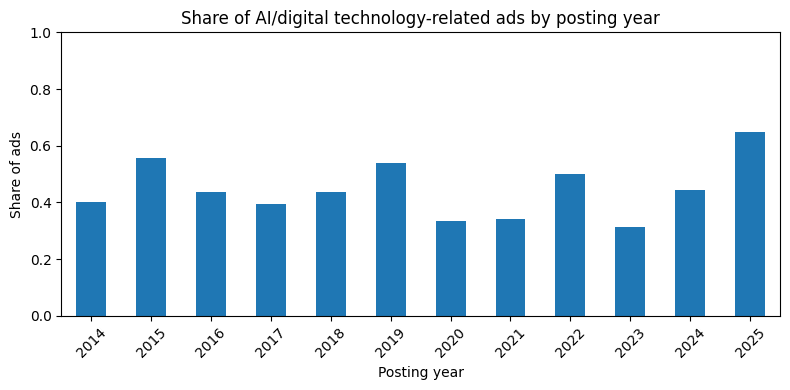

In [107]:
import matplotlib.pyplot as plt


# Keywords are grouped by intensity: 3 = explicit AI, 2 = data/digitalization, 1 = basic IT/digital tools.
ai_keyword_levels = {
    3: [
        "人工智能",
        "AI",
        "机器学习",
        "深度学习",
        "大模型",
        "自然语言",
        "NLP",
        "计算机视觉",
        "图像识别",
        "智能算法",
    ],
    2: [
        "数据分析",
        "数据挖掘",
        "大数据",
        "算法",
        "Python",
        "SQL",
        "数字化",
        "智能化",
    ],
    1: [
        "软件",
        "系统",
        "数据库",
        "信息化",
        "自动化",
        "云计算",
        "云平台",
        "云服务",
        "IT",
        "物联网",
        "嵌入式",
    ],
}


def score_ai_digital_content(row):
    # Score only the text fields that describe the job content.
    text = " ".join(
        str(row[col])
        for col in ["岗位", "岗位描述", "岗位标签"]
        if pd.notna(row[col])
    )

    matched_keywords = []
    score = 0

    # Use the highest keyword level found in the ad text as the final score.
    for level, keywords in ai_keyword_levels.items():
        hits = [kw for kw in keywords if kw.lower() in text.lower()]
        if hits:
            score = max(score, level)
            matched_keywords.extend(hits)

    return pd.Series(
        {
            "ai_digital_score": score,
            "ai_digital_keywords": ", ".join(sorted(set(matched_keywords))),
        }
    )


# Score the deduplicated, parent-matched ad table created above.
ads_encoded = ads_parent_matched.copy()
ads_encoded[["ai_digital_score", "ai_digital_keywords"]] = ads_encoded.apply(
    score_ai_digital_content,
    axis=1,
)
# Treat any nonzero score as an AI/digital technology-related ad for the yearly share.
ads_encoded["is_ai_digital_ad"] = ads_encoded["ai_digital_score"] >= 1
# format="mixed" handles dates with and without a time component.
ads_encoded["posting_year"] = pd.to_datetime(
    ads_encoded["发布时间"],
    errors="coerce",
    format="mixed",
).dt.year

# Aggregate by posting year: total ads, AI/digital ads, share, and average intensity score.
yearly_ai_share = (
    ads_encoded.dropna(subset=["posting_year"])
    .groupby("posting_year")
    .agg(
        ads_count=("id", "count"),
        ai_digital_ads=("is_ai_digital_ad", "sum"),
        ai_digital_share=("is_ai_digital_ad", "mean"),
        avg_ai_digital_score=("ai_digital_score", "mean"),
    )
    .reset_index()
)
yearly_ai_share["posting_year"] = yearly_ai_share["posting_year"].astype(int)
yearly_ai_share["ai_digital_share"] = yearly_ai_share["ai_digital_share"].round(3)
yearly_ai_share["avg_ai_digital_score"] = yearly_ai_share["avg_ai_digital_score"].round(2)

# Show a few scored examples before reporting the yearly trend.
display(
    ads_encoded[
        ["id", "公司名称", "岗位", "发布时间", "ai_digital_score", "ai_digital_keywords"]
    ].head(10)
)
display(yearly_ai_share)

# Simple visualization of the yearly AI/digital ad share.
ax = yearly_ai_share.plot(
    x="posting_year",
    y="ai_digital_share",
    kind="bar",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("Share of AI/digital technology-related ads by posting year")
ax.set_xlabel("Posting year")
ax.set_ylabel("Share of ads")
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 OpenAI API-based AI/digital technology score and yearly trend

This repeats the task in 3.1 using the OpenAI API instead of keyword rules. I use the same 0-3 scale so the results are comparable: `0` = no AI/digital content, `1` = basic digital/IT content, `2` = data/digitalization/technical content, and `3` = explicit AI/ML/deep learning/large-model content. The API results are cached to `output/openai_ai_scores.csv` to avoid re-running paid API calls when the notebook is re-executed.

Cached OpenAI scores: 0
Ads still needing OpenAI scoring: 573
Processing batch 1/573: ads 1-1 of 573
Finished batch 1; total newly scored so far: 1
Processing batch 2/573: ads 2-2 of 573
Finished batch 2; total newly scored so far: 2
Processing batch 3/573: ads 3-3 of 573
Finished batch 3; total newly scored so far: 3
Processing batch 4/573: ads 4-4 of 573
Finished batch 4; total newly scored so far: 4
Processing batch 5/573: ads 5-5 of 573
Finished batch 5; total newly scored so far: 5
Processing batch 6/573: ads 6-6 of 573
Finished batch 6; total newly scored so far: 6
Processing batch 7/573: ads 7-7 of 573
Finished batch 7; total newly scored so far: 7
Processing batch 8/573: ads 8-8 of 573
Finished batch 8; total newly scored so far: 8
Processing batch 9/573: ads 9-9 of 573
Finished batch 9; total newly scored so far: 9
Processing batch 10/573: ads 10-10 of 573
Finished batch 10; total newly scored so far: 10
Processing batch 11/573: ads 11-11 of 573
Finished batch 11; total newly 

,id,公司名称,岗位,发布时间,openai_ai_digital_score,openai_ai_digital_keywords,openai_ai_digital_reason
0,1,中国平安人寿保险股份有限公司广东分公司,兴业银行渠道经理,2023-10-30 00:00:00,0,,岗位是银行保险渠道经理，主要涉及渠道维护、市场活动、客户经营和销售支持，没有明显的软件、数据...
1,2,上海璞泰来新能源科技股份有限公司,研发工程师,2016-11-28 00:00:00,0,"技术开发, 项目管理, 技术支持",岗位主要是材料研发与工艺相关工作，未出现软件、数据、自动化、AI等数字技术关键词；“技术开发...
2,3,嘉亨家化股份有限公司,水电工程师,2020-06-23 00:00:00,1,"发电机组, 高压/低压电工证, 工业配电, 电动机, 机电设备控制电路, 水电安装维修",岗位主要是水电安装、维修和工业配电等传统机电/电工工作，涉及基础电气设备和控制电路，但没有数...
3,4,中国平安人寿保险股份有限公司成都市金堂支公司淮口营销服务部,金融销售培训讲师+周末双休,2023-03-27 00:00:00,0,"培训, 课程安排, 销售培训, 导师",岗位内容主要是金融销售培训与课程安排，没有出现软件、数据、自动化、AI或其他数字技术相关要求...
4,5,成都天箭科技股份有限公司,FPGA开发工程师,2022-07-10 00:00:00,2,"FPGA, 软硬件联调, 逻辑架构, 软件无线电（SDR）, 算法研发, Verilog/V...",岗位以FPGA芯片开发、软硬件联调和上位机软件为主，属于较强的数字/IT硬件开发内容；虽提到...
5,6,北京耐威科技股份有限公司,软件工程师,2015-05-22 00:00:00,1,"软件工程师, 软件维护及升级, 应用软件开发, VC开发环境, MFC, Windows A...",该岗位主要是传统软件开发与维护，涉及VC/MFC、Windows API等IT/软件技术，但...
6,7,上海万科物业服务有限公司,住宅物业项目经理,2023-10-10 00:00:00,0,"ISO9000, 物业管理, 成本控制, 预算, 团队管理",岗位主要是住宅物业运营与管理，涉及质量体系、预算、成本控制和团队管理，但没有明显的软件、数据...
7,8,光大证券股份有限公司,市场风险量化评估岗（权益类证券及衍生品）,2016-04-05 00:00:00,2,"量化评估, 量化/估值模型, 系统实现, 回测检验, 压力测试, MATLAB, 数学和统计软件",岗位核心是量化建模、回测和系统实现，明显属于数据/数字化与量化金融技术内容，但未出现人工智能...
8,9,广西天山电子股份有限公司,销售助理（韩语）,2025-03-19,1,"ERP录入, office办公软件, 变更管理, 订单操作, 发货安排, 库存控制",岗位以销售助理和订单/库存/对账流程为主，涉及ERP和办公软件等基础数字化工具，但没有数据分...
9,10,苏州道森钻采设备股份有限公司,质量工程师,2019-05-09 00:00:00,1,质量数据收集及分析、设计软件包、技术交底、NCR调查分析,岗位以质量管理和工程技术为主，没有AI/算法等内容；但包含日常质量数据分析和设计软件包等基础...


,posting_year,ads_count,openai_ai_digital_ads,openai_ai_digital_share,avg_openai_ai_digital_score
0,2014,10,5,0.500,0.50
1,2015,18,11,0.611,0.67
2,2016,32,16,0.500,0.59
3,2017,28,15,0.536,0.54
4,2018,32,18,0.562,0.56
5,2019,39,21,0.538,0.59
6,2020,45,19,0.422,0.47
7,2021,67,29,0.433,0.48
8,2022,46,29,0.630,0.72
9,2023,178,78,0.438,0.48


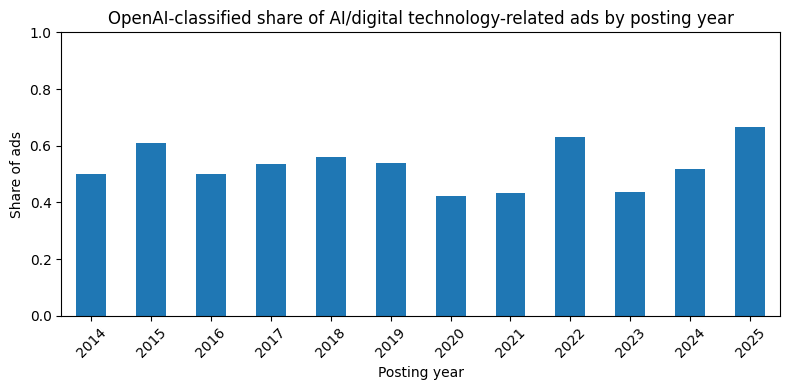

In [108]:
import json
import time

import matplotlib.pyplot as plt
from openai import OpenAI


# OpenAI classification settings and local cache path.
OPENAI_MODEL = "gpt-5.4-mini"
OPENAI_SCORE_VERSION = "expert_prompt_v1_one_ad_per_request"
# Use one ad per request for maximum precision and easier auditing of each model judgment.
OPENAI_BATCH_SIZE = 1
OPENAI_SCORE_CACHE_PATH = PROJECT_ROOT / "output" / "openai_ai_scores.csv"
OPENAI_SCORE_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is not set. Add it to the project .env file before running this cell.")

client = OpenAI(api_key=OPENAI_API_KEY)


def shorten_text(value, max_chars=1200):
    # Keep each API request compact while preserving the beginning of long job descriptions.
    if pd.isna(value):
        return ""

    text = str(value)
    return text[:max_chars]


def build_openai_payload(batch_df):
    # Send only fields needed for scoring, keyed by the original ad id.
    return [
        {
            "id": int(row["id"]),
            "job_title": shorten_text(row["岗位"], 200),
            "job_description": shorten_text(row["岗位描述"], 1200),
            "job_tags": shorten_text(row["岗位标签"], 300),
        }
        for _, row in batch_df.iterrows()
    ]


# Force structured JSON output so the response can be merged back into the DataFrame safely.
score_schema = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "scores": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "properties": {
                    "id": {"type": "integer"},
                    "openai_ai_digital_score": {"type": "integer", "minimum": 0, "maximum": 3},
                    "openai_ai_digital_keywords": {"type": "string"},
                    "openai_ai_digital_reason": {"type": "string"},
                },
                "required": [
                    "id",
                    "openai_ai_digital_score",
                    "openai_ai_digital_keywords",
                    "openai_ai_digital_reason",
                ],
            },
        }
    },
    "required": ["scores"],
}


def classify_ads_with_openai(batch_df):
    # Ask the model to apply the same 0-3 scoring standard used in the keyword method.
    payload = build_openai_payload(batch_df)
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=[
            {
                "role": "system",
                "content": (
                    "You are an expert in AI, digital transformation, and labor-market technology skills. "
                    "Your task is to classify Chinese job ads by their AI/digital technology content. "
                    "Use this 0-3 scale: 0=no AI/digital content; "
                    "1=basic digital/IT content such as software, systems, databases, cloud, automation, or IT; "
                    "2=stronger data or digitalization content such as data analysis, big data, Python/SQL, algorithms, or digital transformation; "
                    "3=explicit AI content such as artificial intelligence, machine learning, deep learning, computer vision, NLP, or large models. "
                    "For every input id, return the score, the relevant keywords or signals, and a brief reason for the score."
                ),
            },
            {
                "role": "user",
                "content": "Classify these ads:\n" + json.dumps(payload, ensure_ascii=False),
            },
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "ai_digital_scores",
                "schema": score_schema,
                "strict": True,
            }
        },
    )

    return json.loads(response.output_text)["scores"]


# Load cached API results for the current prompt version, then only classify ads that are still missing.
if OPENAI_SCORE_CACHE_PATH.exists():
    cached_openai_scores = pd.read_csv(OPENAI_SCORE_CACHE_PATH)
    if "score_version" not in cached_openai_scores.columns:
        print("Ignoring cached OpenAI scores from an earlier prompt version.")
        cached_openai_scores = pd.DataFrame()
    else:
        cached_openai_scores = cached_openai_scores.loc[
            cached_openai_scores["score_version"] == OPENAI_SCORE_VERSION
        ].copy()
else:
    cached_openai_scores = pd.DataFrame()

score_cache_columns = [
    "id",
    "openai_ai_digital_score",
    "openai_ai_digital_keywords",
    "openai_ai_digital_reason",
    "score_version",
]
cached_openai_scores = cached_openai_scores.reindex(columns=score_cache_columns)

cached_ids = set(cached_openai_scores["id"].astype("int64")) if len(cached_openai_scores) else set()
ads_to_classify = ads_parent_matched.loc[~ads_parent_matched["id"].isin(cached_ids)].copy()
total_batches = (len(ads_to_classify) + OPENAI_BATCH_SIZE - 1) // OPENAI_BATCH_SIZE

print(f"Cached OpenAI scores: {len(cached_openai_scores)}")
print(f"Ads still needing OpenAI scoring: {len(ads_to_classify)}")

# Classify only uncached ads in small batches to avoid repeating paid API calls.
new_score_rows = []
for batch_num, start in enumerate(range(0, len(ads_to_classify), OPENAI_BATCH_SIZE), start=1):
    batch = ads_to_classify.iloc[start : start + OPENAI_BATCH_SIZE]
    print(
        f"Processing batch {batch_num}/{total_batches}: "
        f"ads {start + 1}-{start + len(batch)} of {len(ads_to_classify)}"
    )
    batch_score_rows = classify_ads_with_openai(batch)
    for row in batch_score_rows:
        row["score_version"] = OPENAI_SCORE_VERSION

    new_score_rows.extend(batch_score_rows)

    # Save after each request so progress is not lost if the notebook stops midway.
    cached_openai_scores = pd.concat(
        [cached_openai_scores, pd.DataFrame(batch_score_rows)],
        ignore_index=True,
    )
    cached_openai_scores = (
        cached_openai_scores.drop_duplicates(["score_version", "id"], keep="last")
        .sort_values("id")
        .reset_index(drop=True)
    )
    cached_openai_scores.to_csv(OPENAI_SCORE_CACHE_PATH, index=False)
    print(f"Finished batch {batch_num}; total newly scored so far: {len(new_score_rows)}")
    time.sleep(0.2)

openai_scores = cached_openai_scores.copy()

openai_scores["id"] = openai_scores["id"].astype("int64")
openai_scores["openai_ai_digital_score"] = openai_scores["openai_ai_digital_score"].astype("int64")

# Merge model scores back to the ads and compute the same yearly share metrics as in 3.1.
ads_openai_encoded = ads_parent_matched.merge(openai_scores, on="id", how="left")
ads_openai_encoded["is_openai_ai_digital_ad"] = ads_openai_encoded["openai_ai_digital_score"] >= 1
ads_openai_encoded["posting_year"] = pd.to_datetime(
    ads_openai_encoded["发布时间"],
    errors="coerce",
    format="mixed",
).dt.year

yearly_openai_ai_share = (
    ads_openai_encoded.dropna(subset=["posting_year"])
    .groupby("posting_year")
    .agg(
        ads_count=("id", "count"),
        openai_ai_digital_ads=("is_openai_ai_digital_ad", "sum"),
        openai_ai_digital_share=("is_openai_ai_digital_ad", "mean"),
        avg_openai_ai_digital_score=("openai_ai_digital_score", "mean"),
    )
    .reset_index()
)
yearly_openai_ai_share["posting_year"] = yearly_openai_ai_share["posting_year"].astype(int)
yearly_openai_ai_share["openai_ai_digital_share"] = yearly_openai_ai_share["openai_ai_digital_share"].round(3)
yearly_openai_ai_share["avg_openai_ai_digital_score"] = yearly_openai_ai_share["avg_openai_ai_digital_score"].round(2)

# Save the yearly table as a reproducible output artifact.
openai_yearly_share_path = PROJECT_ROOT / "output" / "openai_ai_share_by_year.csv"
openai_yearly_share_path.parent.mkdir(parents=True, exist_ok=True)
yearly_openai_ai_share.to_csv(openai_yearly_share_path, index=False)

display(
    ads_openai_encoded[
        [
            "id",
            "公司名称",
            "岗位",
            "发布时间",
            "openai_ai_digital_score",
            "openai_ai_digital_keywords",
            "openai_ai_digital_reason",
        ]
    ].head(10)
)
display(yearly_openai_ai_share)

# Visualize the model-classified yearly share.
ax = yearly_openai_ai_share.plot(
    x="posting_year",
    y="openai_ai_digital_share",
    kind="bar",
    legend=False,
    figsize=(8, 4),
)
ax.set_title("OpenAI-classified share of AI/digital technology-related ads by posting year")
ax.set_xlabel("Posting year")
ax.set_ylabel("Share of ads")
ax.set_ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "output" / "openai_ai_share_by_year.png", dpi=160)
plt.show()

## 4. Findings and reflections